In [1]:
%pip install torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import random
from tqdm import tqdm
import torch
import torchaudio
from torchaudio.transforms import MelSpectrogram
import os

In [7]:
import json
import random
import unicodedata
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import torch
from torch.utils.data import Dataset
import torchaudio

class AudioDataset(Dataset):
    def __init__(self, audio_dir, label_json, num_classes=4, sr=16000, channels='mono', window=20,):
        super().__init__()
        self.sr = sr
        self.window = window
        self.channels = channels
        self.num_classes = num_classes
        self.loaded_filename, self.loaded_audio = self.get_audio(audio_dir, ext='.wav')
        self.label_dict = self.get_label_dict(label_json)
        self.label_map = {"Unknown":0, "창조":0, "설렁제":0, "경드름": 0, "우조": 1, "계면조": 2, "평조": 3, "아니리": 4}

    def get_audio(self, audio_dir, ext=".wav"):
        """
        지정된 디렉터리에서 특정 확장자의 오디오 파일을 로드
        Args:
            directory_path (str or Path): 오디오 파일이 있는 디렉터리 경로
            file_extension (str): 대상 확장자
        Returns:
            dict: 파일명을 키로, 로드된 오디오 데이터를 값으로 하는 딕셔너리
        """
        audio_dir = Path(audio_dir)
        loaded_filename = []
        loaded_audio = {}
        for audio_file in tqdm(audio_dir.glob(f"*{ext}"), desc="Load Audio"):
            filename = "-".join(audio_file.name.split(".")[0].split("-")[1:])
            filename = unicodedata.normalize('NFC', filename)
            try:
                audio, sr = torchaudio.load(audio_file)
                if self.sr != sr:
                    audio = torchaudio.functional.resample(audio, orig_freq=sr, new_freq=self.sr)
                if self.channels == 'mono' and audio.shape[0] != 1:
                    audio = audio.mean(dim=0, keepdim=True)
                loaded_audio[filename] = audio
                loaded_filename.append(filename)
            except Exception as e: print(f"Error loading {audio_file.name}: {e}")
        return loaded_filename, loaded_audio

    def get_label_dict(self, label_json):
        """
        json 파일에서 filename, start, end, label 정보 추출
        Args: json_file_path: JSON 파일 경로
        Returns: defaultdict: 파일명을 키로, [start, end, label] 리스트를 값으로 하는 default dict
        """
        label_dict = defaultdict(list)
        with open(label_json, 'r', encoding='utf-8') as file: label_data = json.load(file)

        for idx, item in enumerate(tqdm(label_data, desc='Load Label')):
            filename = "-".join(item["file_upload"].split(".")[0].split("-")[1:])
            filename = unicodedata.normalize('NFC', filename)
            if filename not in self.loaded_filename: continue
            for annotation in item["annotations"]:
                for result in annotation["result"]:
                    start, end, label = result["value"]["start"], result["value"]["end"], result["value"]["labels"][0]
                    label_dict[filename].append({"start": start, "end": end, "label": label})
        return label_dict

    def get_label(self, filename, start):
        """
        window가 주어질 때, 초 단위로 비중을 계산하여 가장 비율이 높은 레이블로 labeling
        Args:
            filename (str): Audio filename
            start (float): Start time in seconds
        Returns:
            torch.Tensor: Tensor of shape [window, num_classes] with one-hot encoded labels per second
        """
        labels = torch.zeros((self.window, self.num_classes))
        label_ant = self.label_dict[filename]

        for sec_idx in range(self.window):
            start_sec = start + sec_idx
            end_sec = start_sec + 1

            overlap_ratios = {'Unknown': 1.0}

            for ant in label_ant:
                start_ant, end_ant = ant['start'], ant['end']
                label_name = ant['label']

                if end_ant <= start_sec or start_ant >= end_sec: continue

                overlap_start = max(start_sec, start_ant)
                overlap_end = min(end_sec, end_ant)
                overlap_duration = overlap_end - overlap_start

                if overlap_duration > 0:
                    if label_name not in overlap_ratios: overlap_ratios[label_name] = 0.0

                    overlap_ratios[label_name] += overlap_duration
                    overlap_ratios['Unknown'] -= overlap_duration

            overlap_ratios['Unknown'] = max(0, overlap_ratios['Unknown'])
            max_label = max(overlap_ratios, key=overlap_ratios.get)

            if max_label == 'Unknown': labels[sec_idx, self.label_map['Unknown']] = 1
            else: labels[sec_idx, self.label_map[max_label]] = 1

        return labels

    def __len__(self):
        return len(self.loaded_audio)

    def __getitem__(self, idx):
        filename = self.loaded_filename[idx]
        audio, label = self.loaded_audio[filename], self.label_dict[filename]

        if self.window:
            start_sec = random.randint(0, int(audio.shape[1]/self.sr) - self.window)
            end_sec = start_sec + self.window
            audio = audio[:, start_sec * self.sr:end_sec * self.sr]
            label = self.get_label(filename, start_sec)
            return audio, label, (filename, start_sec)
        else:
            return audio, label

In [ ]:
class MelSpecDatset(AudioDataset):
    def __init__(self, audio_dir, label_json, num_classes=5, sr=16000, channels='mono', window=20, n_fft=2048, hop_length=512, target_bins=64, shift=0.4):
        super().__init__(audio_dir, label_json, num_classes, sr, channels, window)
        self.hop_length = hop_length
        self.target_bins = target_bins
        self.window_frame = self.window * sr // hop_length
        self.mel_cvt = MelSpectrogram(sample_rate=self.sr, n_fft=n_fft, hop_length=hop_length, n_mels = 128)
        self.loaded_mel_spec = self.get_mel()
        self.max_shift = self.target_bins//4 if shift else None
        self.audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav') or f.endswith('.mp3')]

    def get_mel(self):
        mel_spec_dict = {}
        for k, v in tqdm(self.loaded_audio.items(), desc='Load MelSpectrogram'):
            mel_spec = self.mel_cvt(v).squeeze(0)

            # librosa 구현형

            '''
            max_values, _ = torch.max(mel_spec, dim=0, keepdim=True)
            max_values[max_values == 0] = 1.0 # 최댓값이 0인 경우 => 1
            mel_spec = mel_spec / max_values # 가장 강한 음높이 성분 => 1
            '''
            mel_spec = torch.log1p(mel_spec)

            # expand chroma
            '''
            repeat = self.target_bins // chroma.shape[0] + 1
            expanded_chroma = chroma.repeat_interleave(repeat, dim=0)'
            '''

            mel_spec_dict[k] = mel_spec[:self.target_bins, :]
        return mel_spec_dict

    def get_label(self, filename, start):
        labels = torch.zeros((self.window_frame, self.num_classes))
        labels[:, self.label_map['Unknown']] = 1
        label_ant = self.label_dict[filename]

        start_frame = start
        end_frame = start_frame + self.window_frame

        if len(label_ant):
            for ant in label_ant:
                label_start_frame = int((ant['start']/self.hop_length) * self.sr)
                label_end_frame = int((ant['end']/self.hop_length) * self.sr)

                overlap_start = max(start_frame, label_start_frame)
                overlap_end = min(end_frame, label_end_frame)

                if overlap_start < overlap_end:
                    segment_start_idx = int(overlap_start - start_frame)
                    segment_end_idx = int(overlap_end - start_frame)
                    labels[segment_start_idx:segment_end_idx, self.label_map['Unknown']] = 0
                    label_idx = self.label_map.get(ant['label'], self.label_map['Unknown'])
                    labels[segment_start_idx:segment_end_idx, label_idx] = 1

        return labels

    def shift_mel_spec(self, mel_spec):
        if self.max_shift is None: return mel_spec
        prob = 0.8
        if random.random() < prob:
            shift_amount = random.randint(0, self.max_shift)
            mel_spec = torch.roll(mel_spec, shifts=shift_amount, dims=0)

        return mel_spec

    def get_start_time(self, filename, start_frame):
        return start_frame*(self.loaded_audio[filename].shape[1]/self.sr)/self.loaded_mel_spec[filename].shape[1]

    def __getitem__(self, idx):
        filename = self.loaded_filename[idx]
        duration = self.loaded_audio[filename].shape[1]/self.sr
        mel_spec, label = self.loaded_mel_spec[filename], self.label_dict[filename]

        if self.window:
            start_frame = random.randint(0, mel_spec.shape[1] - self.window_frame)
            mel_spec = self.shift_mel_spec(mel_spec[:, start_frame:start_frame+self.window_frame])
            label = self.get_label(filename, start_frame)
            return mel_spec, label, (filename, start_frame, duration)

        return mel_spec, label

Load Audio: 39it [00:09,  4.02it/s]
Load MelSpectrogram: 100%|██████████| 39/39 [00:02<00:00, 18.92it/s]


Filename: 08-이일주-흥보가_흥보_놀보에게_얻어_맞음
Start Frame: 240, Duration: 699.5330625


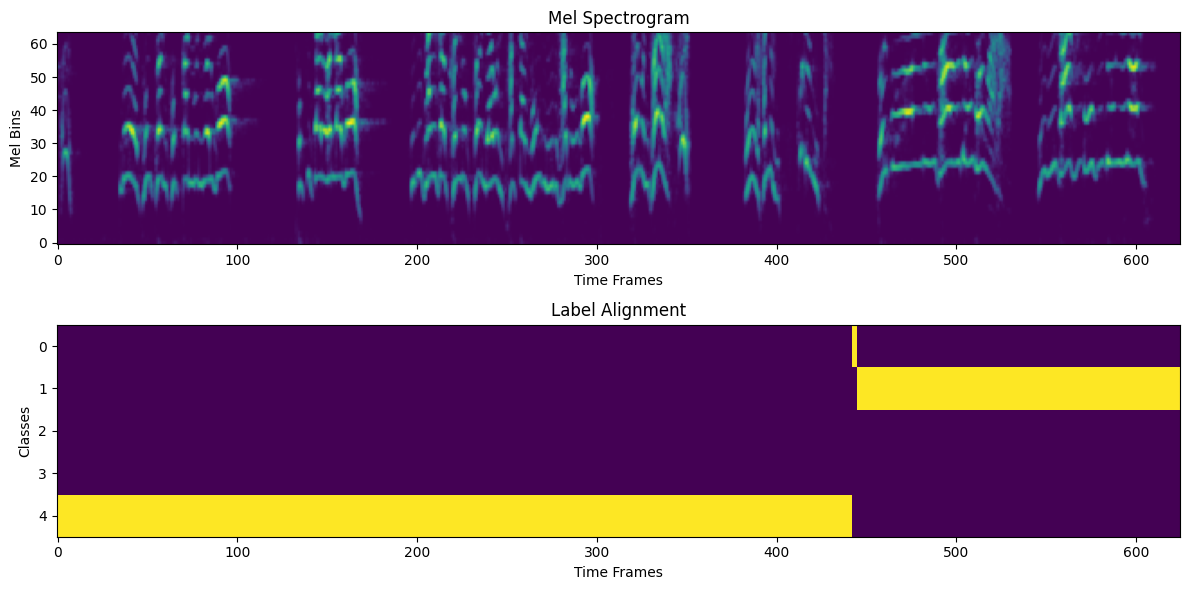

Start Time: 7.68 sec, End Time: 27.68 sec


In [ ]:
import matplotlib.pyplot as plt
import torchaudio
import IPython.display as ipd
sr = 16000
channels = 'mono'
window = 20
n_fft = 2048
hop_length = 512
target_bins = 64
shift = 0.4

audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/data/label.json'

dset = MelSpecDatset(audio_dir, label_dir)

idx = 18
mel_spec, label, (filename, start_frame, duration) = dset[idx]

print(f"Filename: {filename}")
print(f"Start Frame: {start_frame}, Duration: {duration}")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.imshow(mel_spec.numpy(), aspect='auto', origin='lower')
plt.title("Mel Spectrogram")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")

plt.subplot(2, 1, 2)
plt.imshow(label.numpy().T, aspect='auto', interpolation='none')
plt.title("Label Alignment")
plt.xlabel("Time Frames")
plt.ylabel("Classes")

plt.tight_layout()
plt.show()

s_t = start_frame * hop_length
e_t = (start_frame + dset.window_frame) * hop_length

audio_segment = dset.loaded_audio[filename][:, s_t:e_t]

print(f"Start Time: {s_t / sr} sec, End Time: {e_t / sr} sec")

# 플레이백
ipd.display(ipd.Audio(data=audio_segment.numpy(), rate=sr))
